In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt

In [17]:
# df = pd.DataFrame()
#
# for file in [os.path.join("archive",files) for files in os.listdir("archive")]:
#     df = pd.concat([df,pd.read_csv(file)])
# print(df)
# df = pd.read_csv("dummy_normal.csv")
df = pd.read_csv("/system/data/_data.csv")

# df.columns = [
#     "".join([w[0] for w in col.lower().split("_")]) if "_" in col else col.lower()
#     for col in df.columns
# ]

window = 50
df["vibration"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)
df["trend"] = df["vibration"].rolling(window=window,center=True,min_periods=1).mean()
df["vibration"] = df["vibration"] - df["trend"]

df["magnitude"] = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)

vib_mean = df["vibration"].mean()
vib_std = df["vibration"].std()
vib_max_val = df["vibration"].max()
vib_rms = np.sqrt(np.mean(df["vibration"]**2))

mag_mean = df["magnitude"].mean()
mag_std = df["magnitude"].std()
mag_max_val = df["magnitude"].max()
mag_rms = np.sqrt(np.mean(df["magnitude"]**2))
print(df)
print("data length:",len(df))

print("\nvibration mean:", vib_mean)
print("vibration std:", vib_std)
print("vibration max value:", vib_max_val)
print("vibration rms:", vib_rms)


print("\nmagnitude mean:", mag_mean)
print("magnitude std:", mag_std)
print("magnitude max value:", mag_max_val)
print("magnitude rms:", mag_rms)


         ax     ay    az   gx   gy   gz    vibration         trend   magnitude
0     11876   3476  1956  156 -372 -307 -4251.648173  16779.532591  506.921098
1     10596   6884  1040 -188 -154 -207 -4124.399295  16802.974609  319.231891
2     12020  13004   120 -126  310  211   789.177905  16919.543562  395.597017
3     15404  12960  1640  185  666  -30  3337.079228  16860.307138  691.867762
4     12796   5644   872  426  -24 -596 -2747.681414  16760.273466  732.985675
...     ...    ...   ...  ...  ...  ...          ...           ...         ...
8315  14676   8180   292 -328  185  -70   -72.738480  16876.983182  383.026109
8316   9388   2296  2472  168 -268  -71 -6867.492094  16843.310056  324.174336
8317  13292  13420    36 -219  879  226  1990.235259  16898.252240  933.636974
8318  14436   8048  3636  272   80   41   -56.885050  16979.913620  286.469894
8319  16572  12384   204 -179  539  339  3837.601344  16851.435753  661.424977

[8320 rows x 9 columns]
data length: 8320

vibratio

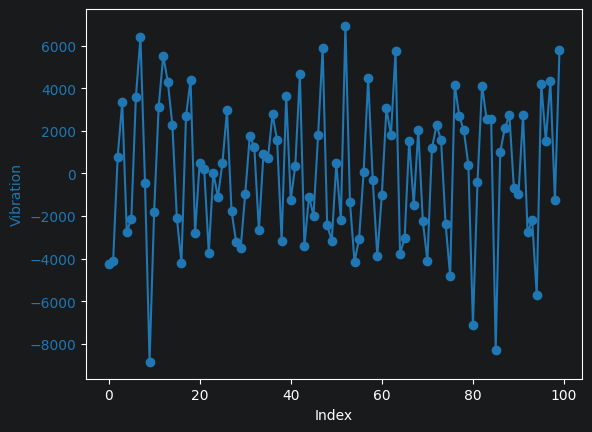

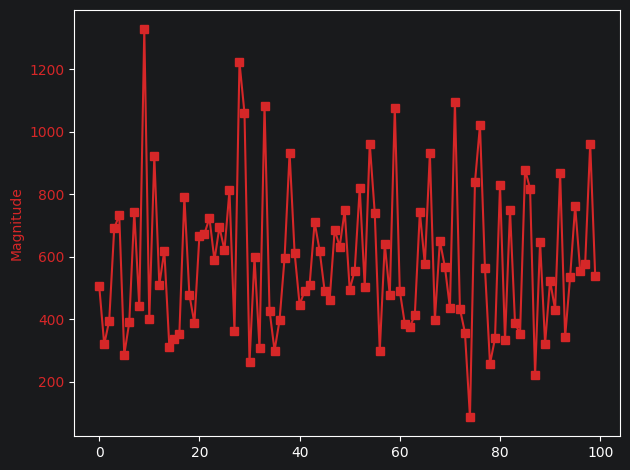

In [19]:
df_feats = df[["vibration","magnitude"]]

interval = 100
x = [i for i in range(len(df_feats.head(interval)))]
y1 = df_feats["vibration"].head(interval).values
y2 = df_feats["magnitude"].head(interval).values

fig, ax1 = plt.subplots()

# Plot Vibration on the left axis
ax1.set_xlabel('Index')
ax1.set_ylabel('Vibration', color='tab:blue')
ax1.plot(x, y1, color='tab:blue', label='Vibration', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

fig, ax2 = plt.subplots()
ax2.set_ylabel('Magnitude', color='tab:red')
ax2.plot(x, y2, color='tab:red', label='Magnitude', marker='s')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('')
fig.tight_layout() # Prevents label clipping
plt.show()

In [20]:
features = []

for i in range(0, len(df)-window,window):
    vib = df_feats["vibration"][i:i+window]
    mag = df_feats["magnitude"][i:i+window]

    features.append({
        "vib_mean": np.mean(vib),
        "vib_std": np.std(vib),
        "vib_rms": np.sqrt(np.mean(vib ** 2)),  # <- this is RMS, not kurtosis
        "vib_max": np.max(vib),

        "mag_mean": np.mean(mag),
        "mag_std": np.std(mag),
        "mag_rms": np.sqrt(np.mean(mag ** 2)),
        "mag_max": np.max(mag),
    })

# convert to DataFrame
df_features = pd.DataFrame(features)

scaler = StandardScaler()
X = scaler.fit_transform(df_features)

In [21]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # assume 5% anomalies
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

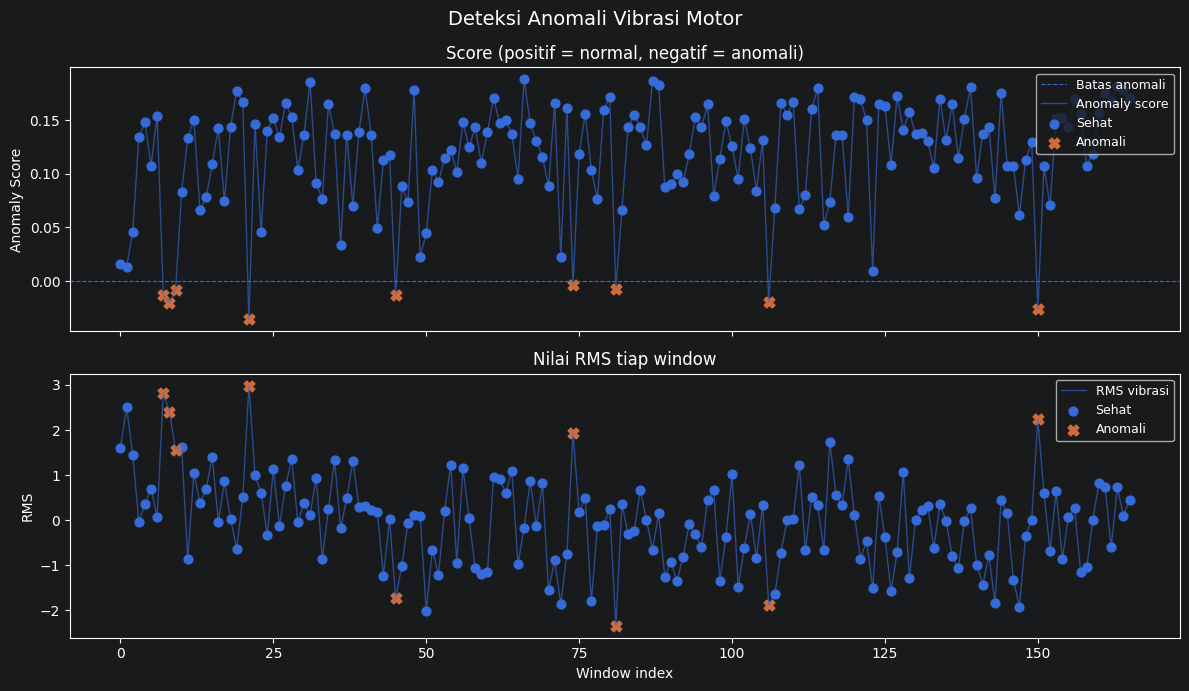

In [22]:
pred, score = model.predict(X),model.decision_function(X)
# === Prepare data ===
x = np.arange(len(score))  # index per window

sehat = pred == 1
anomali = pred == -1

# example RMS from your features (column index 2 = vib_rms)
log_rms = X[:, 2]

# === Plot ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Deteksi Anomali Vibrasi Motor", fontsize=14)

# ── Plot 1: Anomaly Score ─────────────────────────
ax1.axhline(0, linestyle="--", linewidth=0.8, label="Batas anomali")
ax1.plot(x, score, linewidth=1, alpha=0.6, label="Anomaly score")

ax1.scatter(x[sehat], score[sehat], s=40, label="Sehat")
ax1.scatter(x[anomali], score[anomali], s=60, marker="X", label="Anomali")

ax1.set_ylabel("Anomaly Score")
ax1.legend(loc="upper right", fontsize=9)
ax1.set_title("Score (positif = normal, negatif = anomali)")

# ── Plot 2: RMS ───────────────────────────────────
ax2.plot(x, log_rms, linewidth=1, alpha=0.6, label="RMS vibrasi")

ax2.scatter(x[sehat], log_rms[sehat], s=40, label="Sehat")
ax2.scatter(x[anomali], log_rms[anomali], s=60, marker="X", label="Anomali")

ax2.set_xlabel("Window index")
ax2.set_ylabel("RMS")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_title("Nilai RMS tiap window")

plt.tight_layout()
plt.show()

In [23]:
import joblib

# Save model and scaler
joblib.dump(model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved!")

Model saved!


In [24]:
model = joblib.load('isolation_forest_model.pkl')
scaler = joblib.load('scaler.pkl')

def extract_feature(test_df,window=50):
    # test_df = pd.read_csv("dummy_anomaly.csv")

    test_df["vibration"] = np.sqrt(test_df["ax"]**2 + test_df["ay"]**2 + test_df["az"]**2)
    test_df["trend"] = test_df["vibration"].rolling(window=window,center=True,min_periods=1).mean()
    test_df["vibration"] = test_df["vibration"] - test_df["trend"]

    test_df["magnitude"] = np.sqrt(test_df["gx"]**2 + test_df["gy"]**2 + test_df["gz"]**2)

    test_df_feats = test_df.copy()[["temperature","vibration","magnitude"]]
    print(test_df_feats)


    features = []

    for i in range(0, len(test_df_feats)-window,window):
        vib = test_df["vibration"][i:i+window]
        mag = test_df["magnitude"][i:i+window]

        features.append({
            "vib_mean": np.mean(vib),
            "vib_std": np.std(vib),
            "vib_rms": np.sqrt(np.mean(vib ** 2)),  # <- this is RMS, not kurtosis
            "vib_max": np.max(vib),

            "mag_mean": np.mean(mag),
            "mag_std": np.std(mag),
            "mag_rms": np.sqrt(np.mean(mag ** 2)),
            "mag_max": np.max(mag),
        })

    return pd.DataFrame(features)

feats = extract_feature(pd.read_csv("dummy_anomaly.csv"),window)

       temperature  vibration  magnitude
0        17.314019  -0.003263   1.576882
1        17.757678   0.016785   1.807275
2        17.608633   0.012527   1.543264
3        17.451789   0.006426   1.739451
4        17.580624  -0.034441   1.614876
...            ...        ...        ...
11995    16.596028  -0.075809   1.607211
11996    16.652402   0.004444   1.442085
11997    16.654560   0.046236   1.552098
11998    16.653149   0.003784   1.679141
11999    17.191980  -0.018591   1.409119

[12000 rows x 3 columns]


PREDIKSI SEHAT: 92.89%
PREDIKSI TIDAK SEHAT: 7.11%


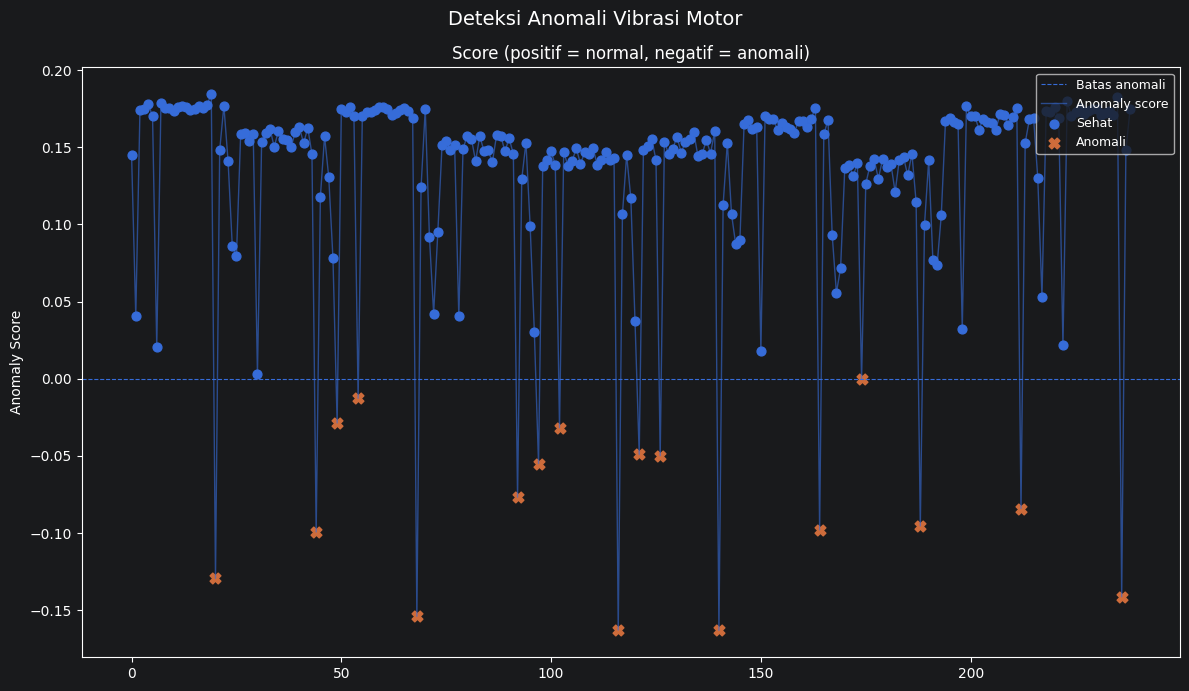

In [25]:
X_test = scaler.fit_transform(feats)
pred = model.predict(X_test)
score = model.decision_function(X_test)
x = np.arange(len(score))  # index per window
